In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from netCDF4 import Dataset
from regrid import regrid, regrid_fast
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
# import pickle
import xarray as xr

In [2]:
dA = Dataset('../aux_data/reanalysis_Aug.nc')
dJ = Dataset('../aux_data/reanalysis_Jul.nc')

lons = dA['longitude']
lats = dA['latitude']
ERA5_lon_grid = np.array([np.array(lons), ] * lats.shape[0])
ERA5_lat_grid = np.array([np.array(lats), ] * lons.shape[0]).T

/tmp/ipykernel_55957/1268143653.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ERA5_lon_grid = np.array([np.array(lons), ] * lats.shape[0])
/tmp/ipykernel_55957/1268143653.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ERA5_lat_grid = np.array([np.array(lats), ] * lons.shape[0]).T


In [4]:
d=Dataset('inputs/conc.nc')
conc12 = np.array(d['sea_ice_conc'])
pslon = np.array(d['longitude'])
pslat = np.array(d['latitude'])

/tmp/ipykernel_55957/3301117981.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conc12 = np.array(d['sea_ice_conc'])
/tmp/ipykernel_55957/3301117981.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pslon = np.array(d['longitude'])
/tmp/ipykernel_55957/3301117981.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration 

In [5]:
ssrd = np.concat([np.array(dJ['ssrd']),np.array(dA['ssrd'])],axis=0)/3600

ssrd_ps=regrid_fast(ssrd,ERA5_lon_grid,ERA5_lat_grid,pslon,pslat)
for i in ssrd_ps:
    i[conc12<0.1]=np.nan
    i[np.isnan(conc12)]=np.nan
    
dt = np.array(list(dJ['valid_time'])+list(dA['valid_time']))

/tmp/ipykernel_55957/1932248181.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ssrd = np.concat([np.array(dJ['ssrd']),np.array(dA['ssrd'])],axis=0)/3600
/home/robbie/custom_modules/regrid.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  xout, yout = proj.transform(crs_wgs, args, np.array(lon_out),np.array(lat_out))
/home/robbie/custom_modules/regrid.py:40: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  xin, yin = proj.transform(crs_wgs, args, np.array(lon_in),np.array(lat_in))
100%|████████████████████████████████████████████████████████

In [6]:
attrs = {"units": "watts per m2 per second"}

ds = xr.DataArray(name='ssrd',
    data=ssrd_ps,
    coords={'time':dt,
            'latitude':(['x','y'],pslat),
            'longitude':(['x','y'],pslon),
           },
                  attrs=attrs,
    dims=['time','x','y'],
)

ds.to_netcdf('ssrd.nc')

(array([ 9025.,  9224., 10697.,  4505.,  2127.,  1146.,   518.,   159.,
           95.,    57.]),
 array([  0.        ,  47.18407088,  94.36814176, 141.55221263,
        188.73628351, 235.92035439, 283.10442527, 330.28849614,
        377.47256702, 424.6566379 , 471.84070878]),
 <BarContainer object of 10 artists>)

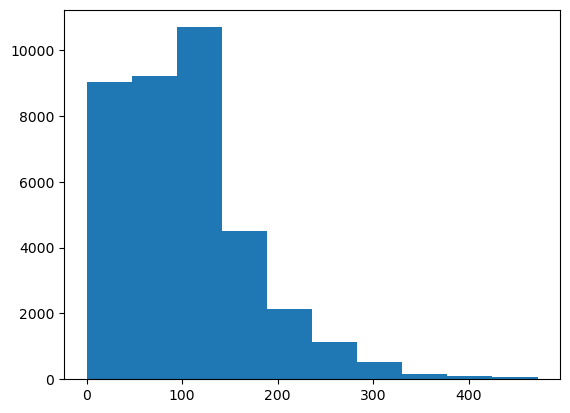

In [7]:
ssrd = Dataset('inputs/ssrd.nc')['ssrd']

plt.hist(ssrd[0].flatten())